In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [35]:
# Read the cleaned dataset
df = pd.read_csv("cleaned_customer_churn.csv")

In [36]:
# Check the data
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
# Number of rows and columns
df.shape

(7043, 20)

In [38]:
# Summary of numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [39]:
# Number of customers who stayed and leftt
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [40]:
# Churn percentage
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

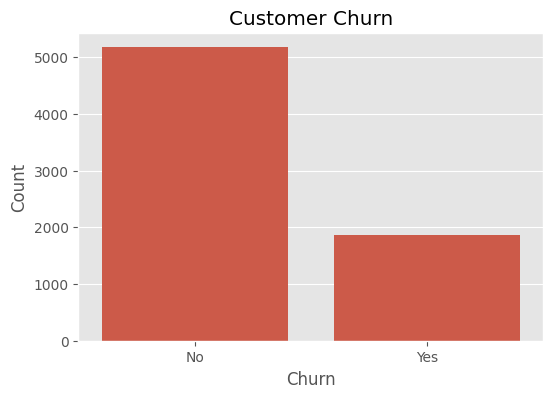

In [41]:
# Churn distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

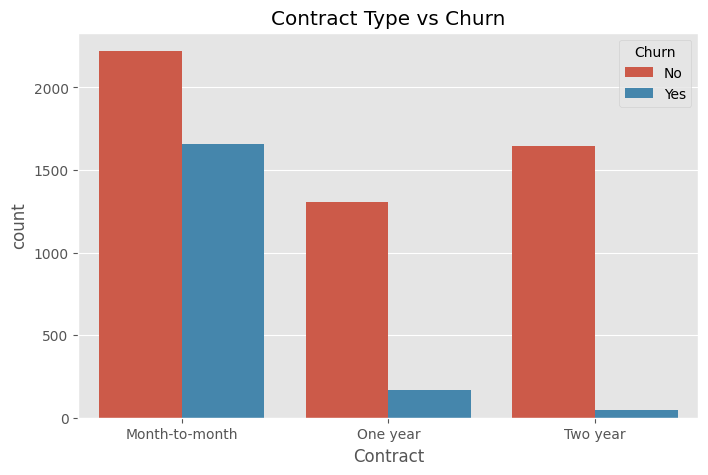

In [42]:
# Compare contract type with churn

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

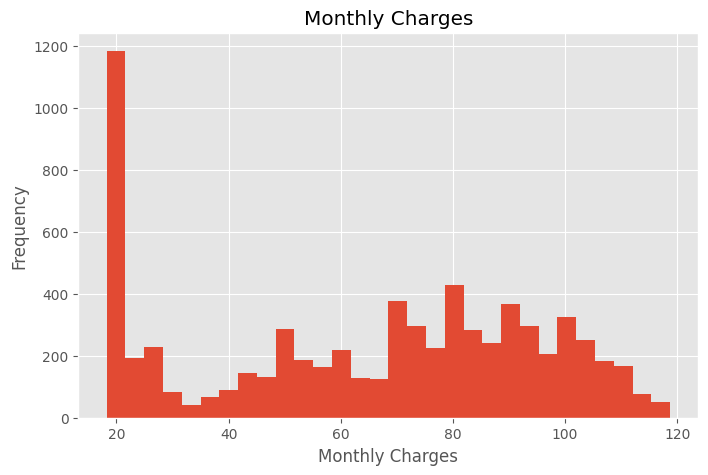

In [43]:
# Distribution of monthly charges

plt.figure(figsize=(8,5))
plt.hist(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

In [44]:
# Convert text columns into numbers for correlation

from sklearn.preprocessing import LabelEncoder
temp = df.copy()
encoder = LabelEncoder()
for column in temp.columns:
    if temp[column].dtype == "object":
        temp[column] = encoder.fit_transform(temp[column])

In [45]:
temp.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [46]:
from sklearn.preprocessing import LabelEncoder

temp = df.copy()

encoder = LabelEncoder()

for col in temp.columns:
    if temp[col].dtype == "object":
        temp[col] = encoder.fit_transform(temp[col].astype(str))

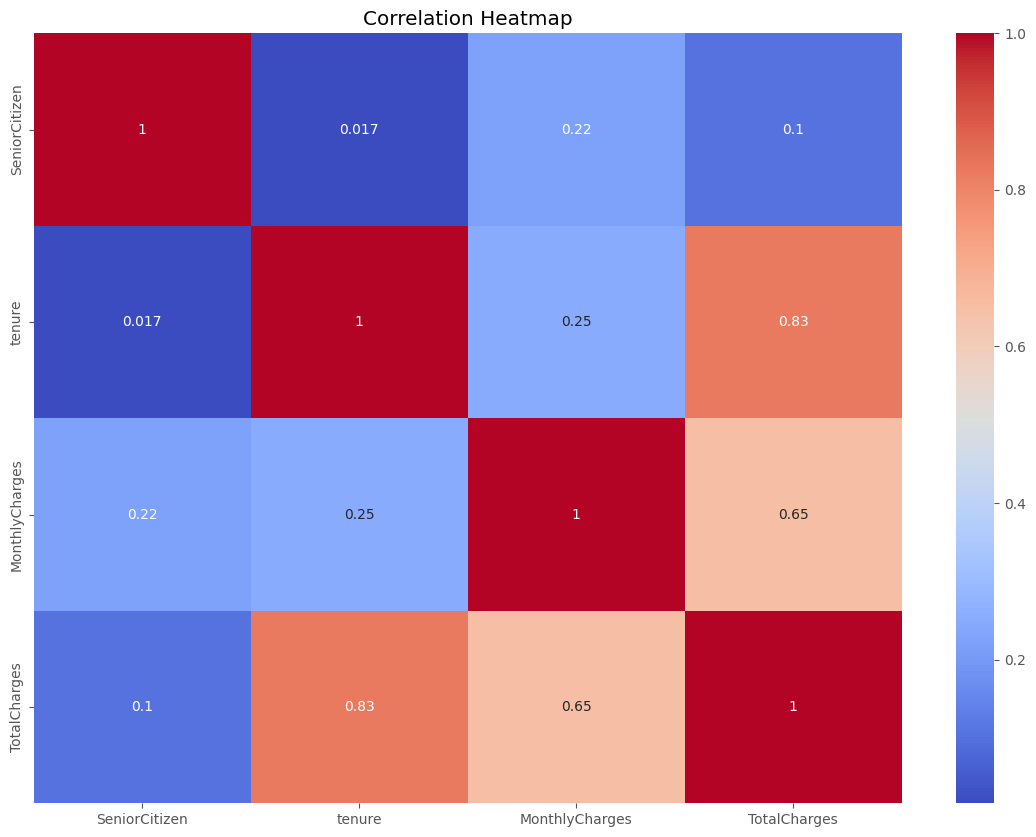

In [47]:
# visualize the het map
plt.figure(figsize=(14,10))

sns.heatmap(temp.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()